The definition of the variables used in the Bookbinder dataset is given below. Use choice variable as dependent variable.

Choice: Whether the customer purchased the The Art History of Florence. 1 corresponds to a purchase and 0 corresponds to a nonpurchase.

Gender: 0 = Female and 1 = Male.

Amount purchased: Total money spent on BBBC books.

Frequency: Total number of purchases in the chosen period (used as a proxy for frequency.)

Last purchase (recency of purchase): Months since last purchase.

First purchase: Months since first purchase.

P_Child: Number of children’s books purchased.

P_Youth: Number of youth books purchased.

P_Cook: Number of cookbooks purchased.

P_DIY: Number of do-it-yourself books purchased.

P_Art: Number of art books purchased.


In [1]:

import pandas as pd
import numpy as np
df = pd.read_excel('https://hogut.weebly.com/uploads/1/8/1/6/18163409/bookbinder2.xls')
df.head()

,Gender,Amount purchased,Frequency,Last purchase,First purchase,P_Child,P_Youth,P_Cook,P_DIY,P_Art,Staus,Choice
0,1,113,8,1,8,0,1,0,0,0,Training,Y
1,1,418,6,11,66,0,2,3,2,3,Training,Y
2,1,336,18,6,32,2,0,1,1,2,Training,Y
3,1,180,16,5,42,2,0,0,1,1,Training,Y
4,0,320,2,3,18,0,0,0,1,2,Training,Y


In [2]:
# Using dataframe df: convert choice to 0(N)and 1(Y)

# Convert 'Choice' column to numerical values (0 for 'N', 1 for 'Y')
df['Choice'] = df['Choice'].map({'N': 0, 'Y': 1})
 #Using dataframe df: Use choice variable as dependent variable.
 #Construct training data and test data  when the status variables having  Training and  Test value.

import pandas as pd
from sklearn.linear_model import LogisticRegression

# Assuming 'df' is your DataFrame
# Filter the DataFrame for training data
training_data = df[df['Staus'] == 'Training']
test_data = df[df['Staus'] == 'Test']
# Define features (X) and target variable (y)
X_train = training_data[['Gender', 'Amount purchased', 'Frequency', 'Last purchase', 'First purchase', 'P_Child', 'P_Youth', 'P_Cook', 'P_DIY', 'P_Art']]
y_train = training_data['Choice']
X_test = test_data[['Gender', 'Amount purchased', 'Frequency', 'Last purchase', 'First purchase', 'P_Child', 'P_Youth', 'P_Cook', 'P_DIY', 'P_Art']]
y_test = test_data['Choice']


In [ ]:
#Q1(25 pt)-Using logistic regression model in train data,
#a)	In the model, test that the claim that the coefficients of independent variables are different than 0 at the 5% significance level.
#b)	Which variables that is significantly different than 0 increase or decrease the probability of Choice=Yes?

In [6]:
#QUESTION1 (a)

import statsmodels.api as sm
import pandas as pd

# Add intercept term
X_train_sm = sm.add_constant(X_train)

# Fit logistic regression model
logit_model = sm.Logit(y_train, X_train_sm)
result = logit_model.fit()

# Display model summary
print(result.summary())

# Create a table with coefficients and p-values
coef_table = pd.DataFrame({
    'Coefficient': result.params,
    'P-value': result.pvalues
})

print(coef_table)

# Identify significant variables at 5% significance level
significant_vars = coef_table[coef_table['P-value'] < 0.05]
print("\nSignificant variables at 5% level:")
print(significant_vars)

#At the 5% significance level, all variables except First purchase and the intercept are statistically significant.
#Therefore, we reject the null hypothesis for all other predictors, meaning they significantly affect the probability of purchase.

Optimization terminated successfully.
         Current function value: 0.435050
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                 Choice   No. Observations:                 1600
Model:                          Logit   Df Residuals:                     1589
Method:                           MLE   Df Model:                           10
Date:                Thu, 23 Apr 2026   Pseudo R-squ.:                  0.2264
Time:                        12:15:41   Log-Likelihood:                -696.08
converged:                       True   LL-Null:                       -899.74
Covariance Type:            nonrobust   LLR p-value:                 2.612e-81
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -0.3515      0.214     -1.640      0.101      -0.772       0.069
Gender     

In [10]:
#QUESTION1 (b)

for var in significant_vars.index:
    coef = significant_vars.loc[var, 'Coefficient']

    if coef > 0:
        print(f"{var}: significantly increases probability of Choice = Yes")
    else:
        print(f"{var}: significantly decreases probability of Choice = Yes")

#The strongest positive predictor is P_Art, indicating that prior interest in art books is the most important driver of purchase behavior.

Gender: significantly decreases probability of Choice = Yes
Amount purchased: significantly increases probability of Choice = Yes
Frequency: significantly decreases probability of Choice = Yes
Last purchase: significantly increases probability of Choice = Yes
P_Child: significantly decreases probability of Choice = Yes
P_Youth: significantly decreases probability of Choice = Yes
P_Cook: significantly decreases probability of Choice = Yes
P_DIY: significantly decreases probability of Choice = Yes
P_Art: significantly increases probability of Choice = Yes


In [11]:
#Q2(15 pt)-Using knn model in train data(choose k based on CV),
#get the performance metric on test data(accuracy,recall, precision confusion matrix). What is the k value chosen based on k?

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix

# Build pipeline with scaling + KNN
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# Try different k values
param_grid = {
    'knn__n_neighbors': list(range(1, 31))
}

# Use cross-validation to choose best k
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)

# Best k value
best_k = grid_search.best_params_['knn__n_neighbors']
print("Best k value:", best_k)

# Best model
best_knn = grid_search.best_estimator_

# Predict on test data
y_pred = best_knn.predict(X_test)

# Performance metrics
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("Recall:", recall)
print("Precision:", precision)
print("Confusion Matrix:")
print(cm)


#The optimal value of k selected using cross-validation is 23.
#The model achieves high accuracy (89.8%), but low recall (25.5%) and moderate precision (38.8%).
#The confusion matrix shows that the model correctly classifies most non-buyers but fails to identify many actual buyers.
#Therefore, despite high accuracy, the KNN model is not effective for this problem due to poor detection of positive cases.


Best k value: 23
Accuracy: 0.8982608695652174
Recall: 0.2549019607843137
Precision: 0.3880597014925373
Confusion Matrix:
[[2014   82]
 [ 152   52]]


In [12]:
#Q3(35 pt)-Get the performance metric on test data (accuracy,recall, precision, confsuion matrix area under curve(auc)) using
#Logistic regression,naive bayes, Multi layer perceptor(MLP) and SVM, ligtGBM and kNN with optimized parameter in Q2.
#Report which methods performs best on these metrics?

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
from sklearn.neighbors import KNeighborsClassifier
import pandas as pd

# Dictionary to store results
results = []

# Logistic Regression
log_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])
log_model.fit(X_train, y_train)
y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

results.append({
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'AUC': roc_auc_score(y_test, y_prob),
    'Confusion Matrix': confusion_matrix(y_test, y_pred)
})

# Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred = nb_model.predict(X_test)
y_prob = nb_model.predict_proba(X_test)[:, 1]

results.append({
    'Model': 'Naive Bayes',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'AUC': roc_auc_score(y_test, y_prob),
    'Confusion Matrix': confusion_matrix(y_test, y_pred)
})

# MLP
mlp_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', MLPClassifier(hidden_layer_sizes=(50,), max_iter=2000, random_state=42))
])
mlp_model.fit(X_train, y_train)
y_pred = mlp_model.predict(X_test)
y_prob = mlp_model.predict_proba(X_test)[:, 1]

results.append({
    'Model': 'MLP',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'AUC': roc_auc_score(y_test, y_prob),
    'Confusion Matrix': confusion_matrix(y_test, y_pred)
})

# SVM
svm_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(probability=True, random_state=42))
])
svm_model.fit(X_train, y_train)
y_pred = svm_model.predict(X_test)
y_prob = svm_model.predict_proba(X_test)[:, 1]

results.append({
    'Model': 'SVM',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'AUC': roc_auc_score(y_test, y_prob),
    'Confusion Matrix': confusion_matrix(y_test, y_pred)
})

# LightGBM
lgbm_model = LGBMClassifier(random_state=42)
lgbm_model.fit(X_train, y_train)
y_pred = lgbm_model.predict(X_test)
y_prob = lgbm_model.predict_proba(X_test)[:, 1]

results.append({
    'Model': 'LightGBM',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'AUC': roc_auc_score(y_test, y_prob),
        'Confusion Matrix': confusion_matrix(y_test, y_pred)
})

# kNN with optimized k from Q2
knn_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier(n_neighbors=best_k))
])
knn_model.fit(X_train, y_train)
y_pred = knn_model.predict(X_test)
y_prob = knn_model.predict_proba(X_test)[:, 1]

results.append({
    'Model': 'kNN',
    'Accuracy': accuracy_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'AUC': roc_auc_score(y_test, y_prob),
    'Confusion Matrix': confusion_matrix(y_test, y_pred)
})

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Show summary table
print(results_df[['Model', 'Accuracy', 'Recall', 'Precision', 'AUC']])

# Show confusion matrices
for i in range(len(results_df)):
    print("\nModel:", results_df.loc[i, 'Model'])
    print(results_df.loc[i, 'Confusion Matrix'])

#Based on the evaluation metrics, Logistic Regression provides the best overall performance. It achieves the highest AUC and recall, making it most effective at identifying potential buyers.
#While SVM has the highest accuracy and precision, its low recall makes it less suitable for marketing purposes.
#Therefore, Logistic Regression is the preferred model for this problem.

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 400, number of negative: 1200
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000489 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 361
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.250000 -> initscore=-1.098612
[LightGBM] [Info] Start training from score -1.098612
                 Model  Accuracy    Recall  Precision       AUC
0  Logistic Regression  0.889565  0.377451   0.377451  0.800695
1          Naive Bayes  0.848261  0.308824   0.232472  0.744416
2                  MLP  0.868696  0.372549   0.304000  0.779766
3                  SVM  0.902609  0.250000   0.418033  0.779261
4             LightGBM  0.857391  0.348039   0.

AUC: 0.8006953019757522
Best Threshold: 0.17622431429427324
Maximum Expected Profit: 1053.4
Threshold       0.176224
TP            168.000000
FP            796.000000
TN           1300.000000
FN             36.000000
Profit       1053.400000
Name: 245, dtype: float64
Number of customers to target: 964
      Predicted_Probability Target
1600               0.539889    Yes
1601               0.529750    Yes
1602               0.594754    Yes
1603               0.297262    Yes
1604               0.397596    Yes


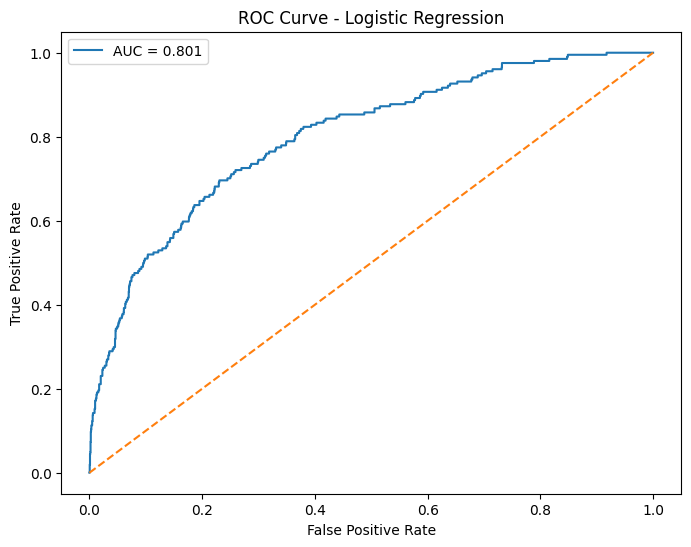

In [14]:
#Q4(25 pt)-There is a need to evaluate the effectiveness of the current direct mail program and assess whether predictive modeling
#can be leveraged to enhance targeting and increase response rates.
# Assume that you make profit of 10 $ by selling a book and the cost of sending mail is 0.65 $.
# Based on the logistic model, which customers should Bookbinders target on test data?
#What is the expected profits if these customers are targeted?
#Hint :
#To evaluate the direct mail program, use an ROC curve to assess the logistic model’s ability to predict buyers.
#The curve plots True Positive Rate vs. False Positive Rate, and a high AUC shows the model is effective.
# To decide who to target, calculate profit for different probability thresholds:
# Profit = (True Positives × $9.35) - (False Positives × $0.65).
#True positive profit is $93.5 becuase revenue is $10 and there is a $0.65 cost of sending mail.
#Bookbinders should target customers with probabilities above the threshold that maximizes profit,
# improving targeting and response rates compared to the current program


from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Fit logistic regression model
log_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

# Predicted probabilities for test data
y_prob = log_model.predict_proba(X_test)[:, 1]

# ROC and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_value = roc_auc_score(y_test, y_prob)

print("AUC:", auc_value)

# Evaluate profit at different thresholds
profit_results = []

for threshold in thresholds:
    y_pred_thresh = (y_prob >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_thresh).ravel()

    # Profit formula
    profit = (tp * 9.35) - (fp * 0.65)

    profit_results.append({
        'Threshold': threshold,
        'TP': tp,
        'FP': fp,
        'TN': tn,
        'FN': fn,
        'Profit': profit
    })

profit_df = pd.DataFrame(profit_results)

# Best threshold
best_row = profit_df.loc[profit_df['Profit'].idxmax()]

best_threshold = best_row['Threshold']
best_profit = best_row['Profit']

print("Best Threshold:", best_threshold)
print("Maximum Expected Profit:", best_profit)
print(best_row)

# Customers to target
target_customers = test_data.copy()
target_customers['Predicted_Probability'] = y_prob
target_customers['Target'] = np.where(
    target_customers['Predicted_Probability'] >= best_threshold,
    'Yes',
    'No'
)

# Customers that should be targeted
customers_to_target = target_customers[target_customers['Target'] == 'Yes']

print("Number of customers to target:", len(customers_to_target))
print(customers_to_target[['Predicted_Probability', 'Target']].head())

# ROC Curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'AUC = {auc_value:.3f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Logistic Regression')
plt.legend()
plt.show()

#Compared to a non-targeted mailing strategy, using logistic regression significantly improves profitability.
#Bookbinders should adopt this predictive targeting approach to increase response rates and reduce wasted mailing costs.
#The relatively low threshold (0.176) indicates that it is profitable to target a broader group of customers, since the gain from true buyers outweighs the cost of contacting non-buyers.